In [35]:
import sys
import math
import numpy as np

from tensorflow.keras import * 
from keras.datasets import mnist 
from tensorflow.keras.layers import * 
from tensorflow.keras.models import load_model, save_model 

import tensorflow.keras.utils as utils
import tensorflow as tf 
import keras
import matplotlib.pyplot as plt 

np.random.seed(7)

print('Python version: ', sys.version)
print('TensorFlow version: ', tf.__version__)
print('Keras version: ', keras.__version__)

Python version:  3.9.12 (main, Apr  4 2022, 05:22:27) [MSC v.1916 64 bit (AMD64)]
TensorFlow version:  2.6.0
Keras version:  2.6.0


In [ ]:
def train(x_train, y_train, x_test, y_test, batch_size=64, epochs=100): 
    inputs = Input(shape=x_train.shape[1:])
    x = Conv2D(4, kernel_size=(3,3), strides=(1,1), padding='same')(inputs)
    x = ReLU()(x)
    x = MaxPool2D((2,2),strides=(2,2), padding="same")(x)

    x = Flatten()(x)
    x = Dense(20)(x)

    x = ReLU()(x)
    x = Dense(10)(x)
    predictions = Softmax()(x)

    model = Model(inputs=inputs, outputs=predictions)
    model.compile(loss='categorical_crossentropy',
                  optimizer='adam', 
                  metrics=['accuracy'])
    model.summary()

    history = model.fit(x_train, y_train,
                        batch_size=batch_size,
                        epochs=epochs,
                        verbose=2,
                        validation_data=(x_test, y_test),
                        shuffle=True)   
    
    save_model(model, model_name)
    del model
    tf.keras.backend.clear_session()
    return history


In [46]:
model_name = 'neural_network_model.h5'

epochs = 5
num_classes = 10

(x_train, y_train_num), (x_test, y_test_num) = mnist.load_data() 
print(x_train.shape[0], 'train samples')
print(x_test.shape[0], 'test samples')

x_train = x_train.reshape(x_train.shape[0], x_train.shape[1], x_train.shape[2], 1)
x_test = x_test.reshape(x_test.shape[0], x_test.shape[1], x_test.shape[2], 1)
y_train = utils.to_categorical(y_train_num, num_classes)
y_test = utils.to_categorical(y_test_num, num_classes)

x_test = x_test/255
x_train = x_train/255
print("data range", x_test.min(), x_test.max())

history = train(x_train, y_train, x_test, y_test, batch_size=64, epochs=epochs)


60000 train samples
10000 test samples
data range 0.0 1.0
Model: "model_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_2 (InputLayer)         [(None, 28, 28, 1)]       0         
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 28, 28, 3)         30        
_________________________________________________________________
re_lu_2 (ReLU)               (None, 28, 28, 3)         0         
_________________________________________________________________
max_pooling2d_1 (MaxPooling2 (None, 14, 14, 3)         0         
_________________________________________________________________
flatten_1 (Flatten)          (None, 588)               0         
_________________________________________________________________
dense_2 (Dense)              (None, 20)                11780     
_________________________________________________________________
r

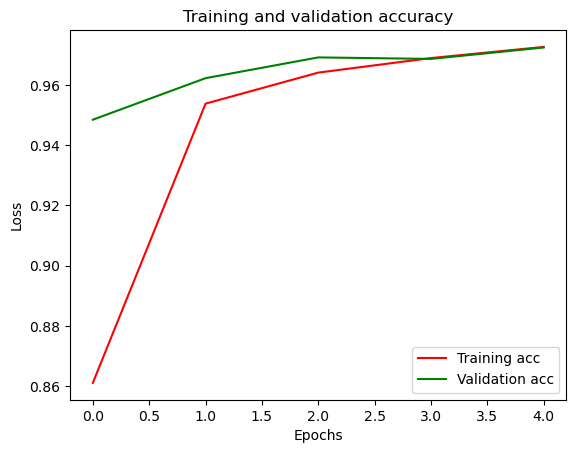

In [47]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
plt.plot(range(0, epochs), acc, color='red', label='Training acc')
plt.plot(range(0, epochs), val_acc, color='green', label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()